# Horse Survival Classification

## Data Loading

In [1]:
# Importing dataset via kaggle

!kaggle datasets download -d yasserh/horse-survival-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/horse-survival-dataset
License(s): CC0-1.0
  0%|                                               | 0.00/8.43k [00:00<?, ?B/s]
100%|██████████████████████████████████████| 8.43k/8.43k [00:00<00:00, 21.0MB/s]


In [2]:
# Exporting dataset from zipfile

import zipfile
zip_ref = zipfile.ZipFile('/home/bhxveshhh/ML/Horse Survival Classification/horse-survival-dataset.zip', 'r')
zip_ref.extractall('/home/bhxveshhh/ML/Horse Survival Classification')
zip_ref.close()

## Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('horse.csv')

In [17]:
df.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


In [18]:
df.shape

(299, 28)

In [7]:
df.size

8372

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    object 
 1   age                    299 non-null    object 
 2   hospital_number        299 non-null    int64  
 3   rectal_temp            239 non-null    float64
 4   pulse                  275 non-null    float64
 5   respiratory_rate       241 non-null    float64
 6   temp_of_extremities    243 non-null    object 
 7   peripheral_pulse       230 non-null    object 
 8   mucous_membrane        252 non-null    object 
 9   capillary_refill_time  267 non-null    object 
 10  pain                   244 non-null    object 
 11  peristalsis            255 non-null    object 
 12  abdominal_distention   243 non-null    object 
 13  nasogastric_tube       195 non-null    object 
 14  nasogastric_reflux     193 non-null    object 
 15  nasoga

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hospital_number,299.0,1.087733e+06,1.532032e+06,518476.0,528904.0,530301.0,534736.00,5305629.0
rectal_temp,239.0,3.816862e+01,7.337444e-01,35.4,37.8,38.2,38.50,40.8
pulse,275.0,7.200000e+01,2.864622e+01,30.0,48.0,64.0,88.00,184.0
respiratory_rate,241.0,3.046058e+01,1.766610e+01,8.0,18.0,25.0,36.00,96.0
nasogastric_reflux_ph,53.0,4.707547e+00,1.982311e+00,1.0,3.0,5.0,6.50,7.5
packed_cell_volume,270.0,4.630741e+01,1.043674e+01,23.0,38.0,45.0,52.00,75.0
total_protein,266.0,2.427444e+01,2.736419e+01,3.3,6.5,7.5,56.75,89.0
abdomo_protein,101.0,3.039604e+00,1.967947e+00,0.1,2.0,2.3,3.90,10.1
lesion_1,299.0,3.659709e+03,5.408472e+03,0.0,2111.5,2322.0,3209.00,41110.0
lesion_2,299.0,9.052843e+01,6.506371e+02,0.0,0.0,0.0,0.00,7111.0


In [10]:
df.isnull().sum()

surgery                    0
age                        0
hospital_number            0
rectal_temp               60
pulse                     24
respiratory_rate          58
temp_of_extremities       56
peripheral_pulse          69
mucous_membrane           47
capillary_refill_time     32
pain                      55
peristalsis               44
abdominal_distention      56
nasogastric_tube         104
nasogastric_reflux       106
nasogastric_reflux_ph    246
rectal_exam_feces        102
abdomen                  118
packed_cell_volume        29
total_protein             33
abdomo_appearance        165
abdomo_protein           198
outcome                    0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

surgery                    2
age                        2
hospital_number          283
rectal_temp               40
pulse                     52
respiratory_rate          40
temp_of_extremities        4
peripheral_pulse           4
mucous_membrane            6
capillary_refill_time      3
pain                       5
peristalsis                4
abdominal_distention       4
nasogastric_tube           3
nasogastric_reflux         3
nasogastric_reflux_ph     20
rectal_exam_feces          4
abdomen                    5
packed_cell_volume        50
total_protein             80
abdomo_appearance          3
abdomo_protein            37
outcome                    3
surgical_lesion            2
lesion_1                  61
lesion_2                   6
lesion_3                   2
cp_data                    2
dtype: int64

## Data Preprocessing

In [19]:
# Filling numerical value with mean and categorical with mode

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

In [20]:
# Label encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in df.columns:
    df[col] = encoder.fit_transform(df[col].values)

In [21]:
X = df.drop('cp_data', axis=1)
y = df['cp_data']

In [22]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

In [23]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
logistic_clf = LogisticRegression()
ridge_clf = RidgeClassifier()
xgboost_clf = XGBClassifier()
random_forest_clf = RandomForestClassifier()
ada_boost_clf = AdaBoostClassifier()
grad_boost_clf = GradientBoostingClassifier()
bagging_clf = BaggingClassifier()
decision_tree_clf = DecisionTreeClassifier()
svm_clf = SVC()

In [25]:
model_li = [logistic_clf, ridge_clf, xgboost_clf, random_forest_clf, 
            ada_boost_clf, grad_boost_clf, bagging_clf, decision_tree_clf, svm_clf]

scores = []
for model in model_li:
    model.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

print(scores)

[0.75, 0.7666666666666667, 0.8166666666666667, 0.8333333333333334, 0.8166666666666667, 0.85, 0.8166666666666667, 0.8166666666666667, 0.6333333333333333]


## Model Evaluation

Model: LogisticRegression
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.81        39
           1       0.67      0.57      0.62        21

    accuracy                           0.75        60
   macro avg       0.73      0.71      0.72        60
weighted avg       0.74      0.75      0.75        60

Confusion Matrix:
 [[33  6]
 [ 9 12]]


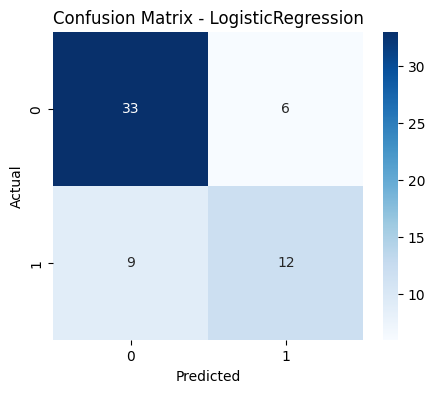

Model: RidgeClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82        39
           1       0.68      0.62      0.65        21

    accuracy                           0.77        60
   macro avg       0.74      0.73      0.74        60
weighted avg       0.76      0.77      0.76        60

Confusion Matrix:
 [[33  6]
 [ 8 13]]


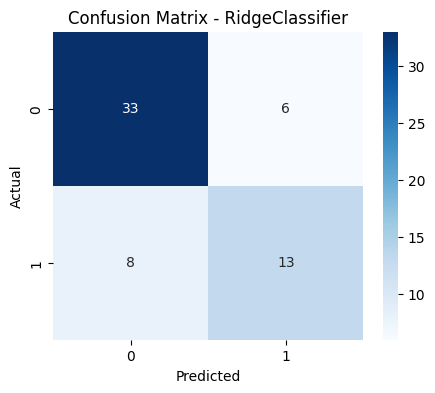

Model: XGBClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87        39
           1       0.81      0.62      0.70        21

    accuracy                           0.82        60
   macro avg       0.82      0.77      0.79        60
weighted avg       0.82      0.82      0.81        60

Confusion Matrix:
 [[36  3]
 [ 8 13]]


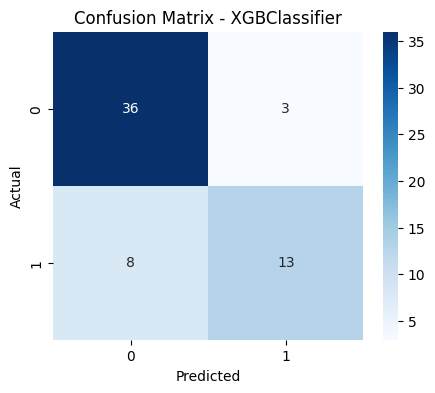

Model: RandomForestClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.97      0.87        39
           1       0.92      0.52      0.67        21

    accuracy                           0.82        60
   macro avg       0.85      0.75      0.77        60
weighted avg       0.84      0.82      0.80        60

Confusion Matrix:
 [[38  1]
 [10 11]]


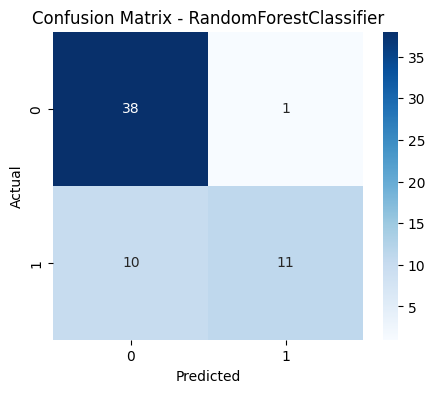

Model: AdaBoostClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87        39
           1       0.86      0.57      0.69        21

    accuracy                           0.82        60
   macro avg       0.83      0.76      0.78        60
weighted avg       0.82      0.82      0.81        60

Confusion Matrix:
 [[37  2]
 [ 9 12]]


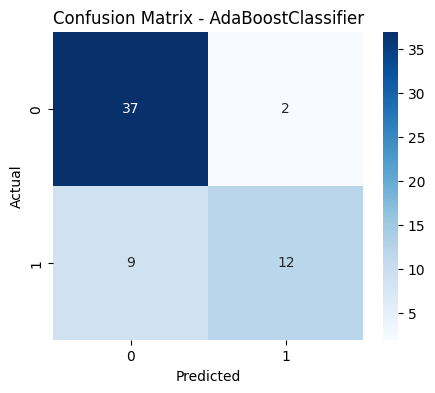

Model: GradientBoostingClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88        39
           1       0.82      0.67      0.74        21

    accuracy                           0.83        60
   macro avg       0.83      0.79      0.81        60
weighted avg       0.83      0.83      0.83        60

Confusion Matrix:
 [[36  3]
 [ 7 14]]


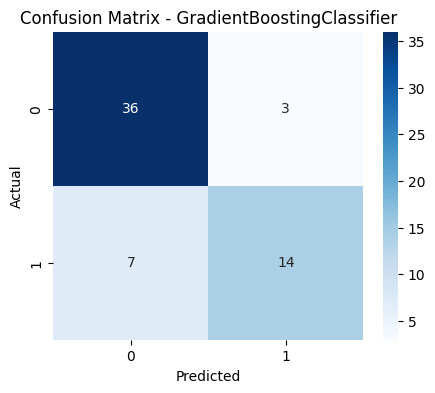

Model: BaggingClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.88        39
           1       0.92      0.57      0.71        21

    accuracy                           0.83        60
   macro avg       0.87      0.77      0.79        60
weighted avg       0.85      0.83      0.82        60

Confusion Matrix:
 [[38  1]
 [ 9 12]]


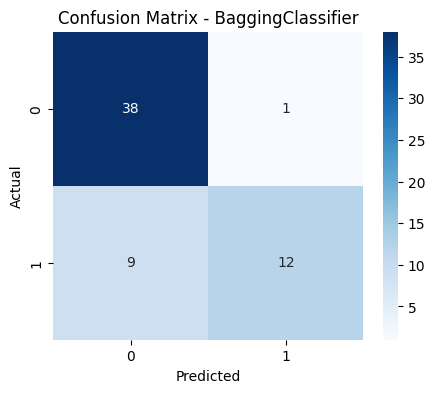

Model: DecisionTreeClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86        39
           1       0.75      0.71      0.73        21

    accuracy                           0.82        60
   macro avg       0.80      0.79      0.80        60
weighted avg       0.81      0.82      0.82        60

Confusion Matrix:
 [[34  5]
 [ 6 15]]


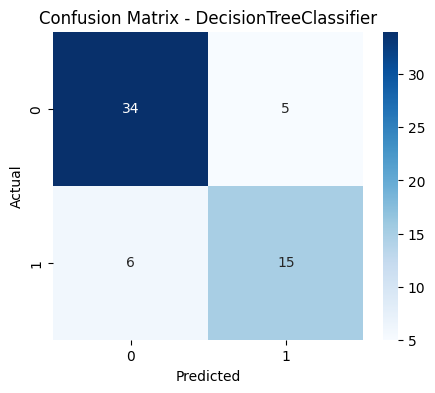

Model: SVC
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.77      0.73        39
           1       0.47      0.38      0.42        21

    accuracy                           0.63        60
   macro avg       0.58      0.58      0.58        60
weighted avg       0.62      0.63      0.62        60

Confusion Matrix:
 [[30  9]
 [13  8]]


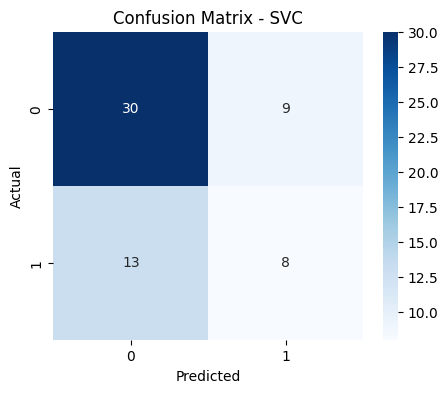

In [26]:
for model in model_li:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Model: {model.__class__.__name__}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Plot the confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")
    plt.show()